In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:

from google.colab import drive

drive.mount('/content/drive')
penguins = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/penguins_simple.csv' , sep = ';') #replace filename.csv with your csv file name
penguins.head(15)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Species,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie,39.1,18.7,181.0,3750.0,MALE
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,39.3,20.6,190.0,3650.0,MALE
5,Adelie,38.9,17.8,181.0,3625.0,FEMALE
6,Adelie,39.2,19.6,195.0,4675.0,MALE
7,Adelie,41.1,17.6,182.0,3200.0,FEMALE
8,Adelie,38.6,21.2,191.0,3800.0,MALE
9,Adelie,34.6,21.1,198.0,4400.0,MALE


In [3]:
# Group by species and calculate the mean of 'Body Mass'
species_avg_mass = penguins.groupby('Species')['Body Mass (g)'].mean()
species_avg_mass

,Body Mass (g)
Species,
Adelie,3706.164384
Chinstrap,3733.088235
Gentoo,5092.436975


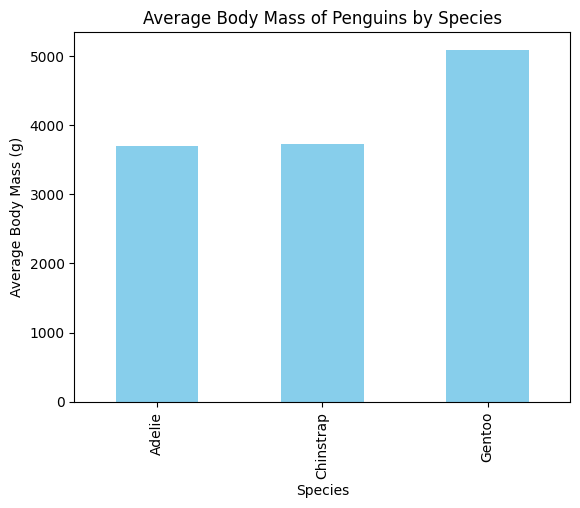

In [26]:
# Plotting a bar chart
species_avg_mass.plot(kind='bar', color='skyblue')

plt.title('Average Body Mass of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.show()

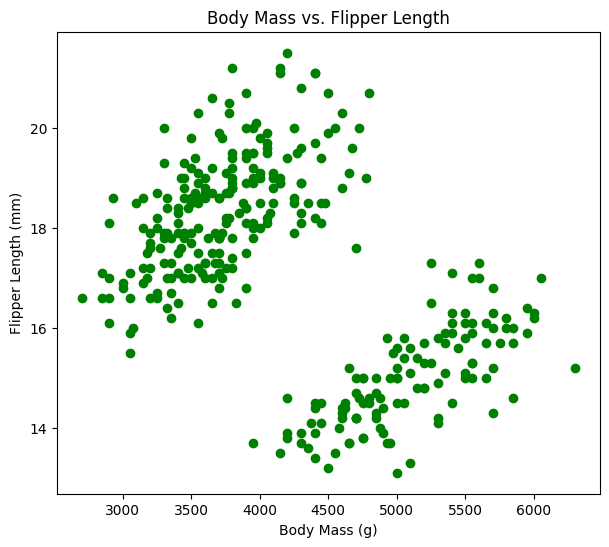

In [29]:
plt.figure(figsize=(7,6))

# Scatter plot of 'Body Mass' vs 'Flipper Length'
plt.scatter(penguins['Body Mass (g)'], penguins['Culmen Depth (mm)'], color='green')

plt.title('Body Mass vs. Flipper Length')
plt.xlabel('Body Mass (g)')
plt.ylabel('Flipper Length (mm)')
plt.show()

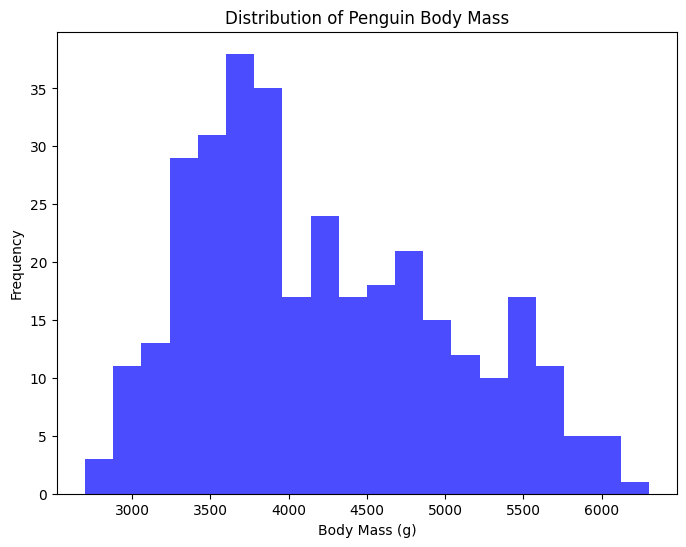

In [31]:
plt.figure(figsize=(8,6))

# Histogram for 'Body Mass'
plt.hist(penguins['Body Mass (g)'].dropna(), bins=20, color='blue', alpha=0.7)

plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.show()

<Figure size 800x600 with 0 Axes>

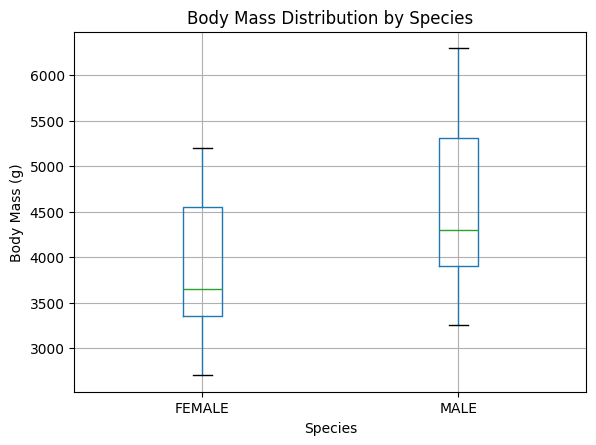

In [32]:
plt.figure(figsize=(8,6))

# Boxplot of 'Body Mass' by 'Species'
penguins.boxplot(column='Body Mass (g)', by='Species')

plt.title('Body Mass Distribution by Species')
plt.suptitle('')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

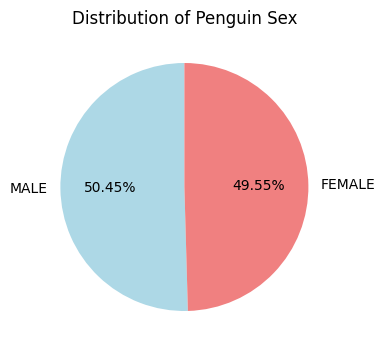

In [37]:
# Pie chart showing the percentage of male and female penguins
sex_counts = penguins['Sex'].value_counts()

plt.figure(figsize=(4,6))
sex_counts.plot(kind='pie', autopct='%1.2f%%', colors=['lightblue', 'lightcoral'], startangle=90)

plt.title('Distribution of Penguin Sex')
plt.ylabel('')  # Remove the label on the y-axis
plt.show()

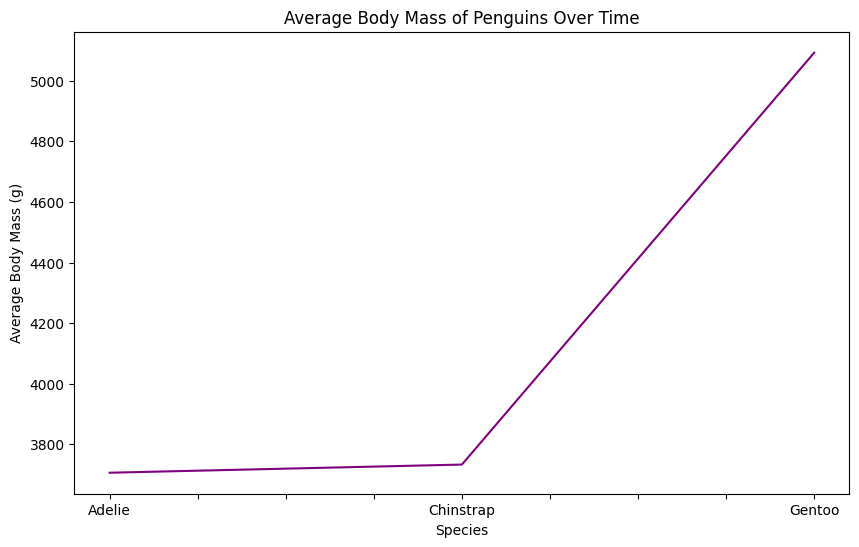

In [9]:
# Assuming you have a 'Year' column, if not, replace it with something relevant
plt.figure(figsize=(10,6))

# Line plot for Body Mass over Year (this assumes a 'Year' column exists in your data)
penguins.groupby('Species')['Body Mass (g)'].mean().plot(kind='line', color='purple')

plt.title('Average Body Mass of Penguins Over Time')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.show()


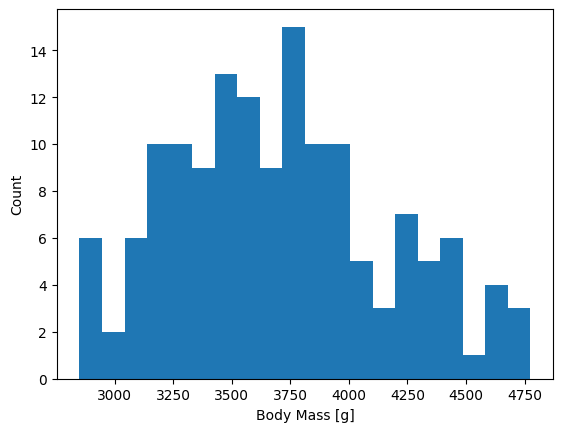

In [10]:
adelie = penguins[penguins['Species']== 'Adelie']
plt.hist(x = adelie['Body Mass (g)'], bins = 20) #bins: divides your data and creates 20 separate bins to give a much granual view
plt.xlabel('Body Mass [g]') # we added x label
plt.ylabel('Count'); #we added y label

**Is there a way to put all the species in one histogram ?**

In [11]:
# Step 1: filter 3 different dataframes for the individual species.

adelie = penguins[penguins['Species']== 'Adelie']
gentoo = penguins[penguins['Species']== 'Gentoo']
chinstrap = penguins[penguins['Species']== 'Chinstrap']

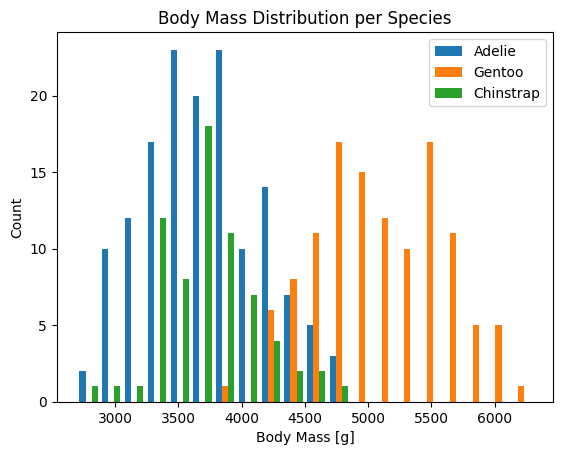

In [39]:
# Step 2: create histograms for all of the species and their body mass in one plot

listofdfs = [adelie['Body Mass (g)'], gentoo['Body Mass (g)'], chinstrap['Body Mass (g)']]

plt.hist(x = listofdfs, label =['Adelie', 'Gentoo', 'Chinstrap'], bins = 20)

plt.legend()
plt.xlabel('Body Mass [g]')
plt.ylabel('Count')
plt.title("Body Mass Distribution per Species");

#rwidth: Set Width for Bars in Bar Plot

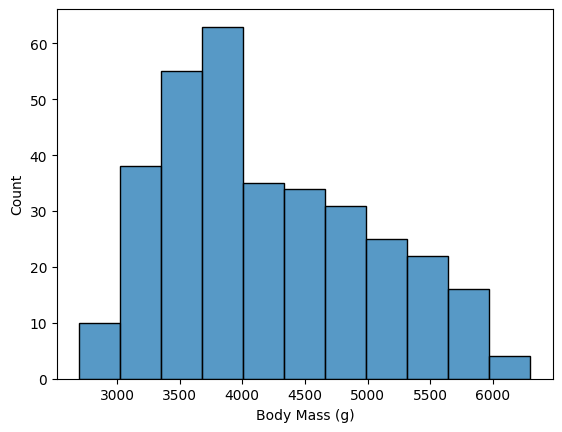

In [40]:
# Let's start with basic
sns.histplot(x = 'Body Mass (g)',data= penguins); # we pass the dataframe

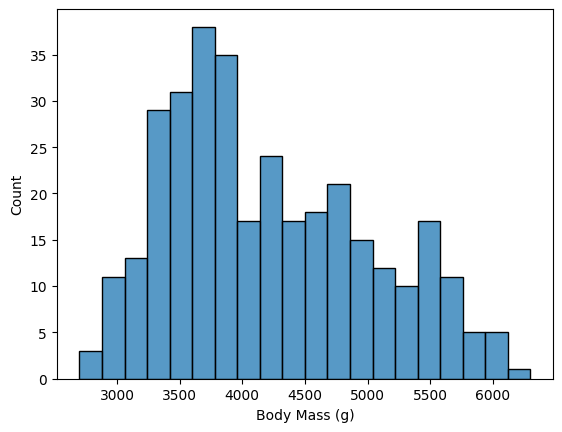

In [43]:
sns.histplot(x = 'Body Mass (g)', bins =20, data= penguins);


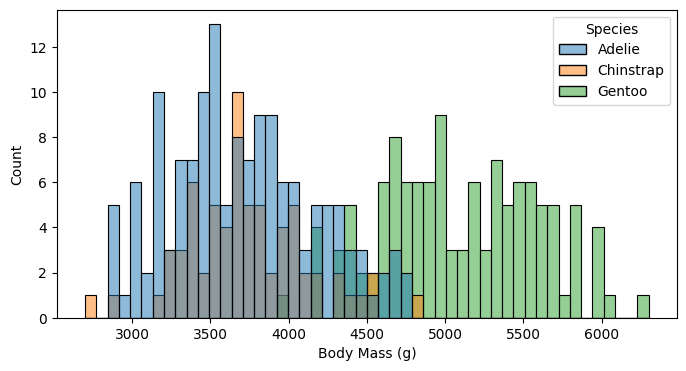

In [47]:
plt.figure(figsize=(8,4)) # using matplotlib we can change the size of the graph

sns.histplot(x = 'Body Mass (g)',
             hue = 'Species', bins=50, data= penguins);

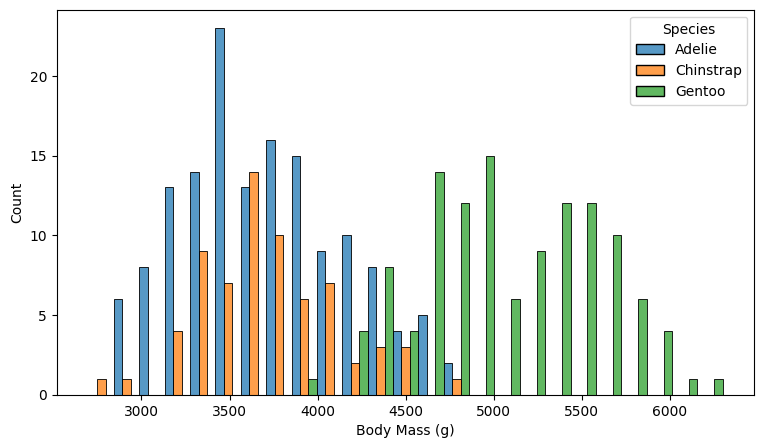

In [16]:
# To see them separately we are adding multiple parameter

plt.figure(figsize=(9,5))

sns.histplot(x = 'Body Mass (g)',
             hue = 'Species',  bins=25,
             multiple="dodge", # options are "layer", "dodge", "stack", "fill"
            data= penguins);

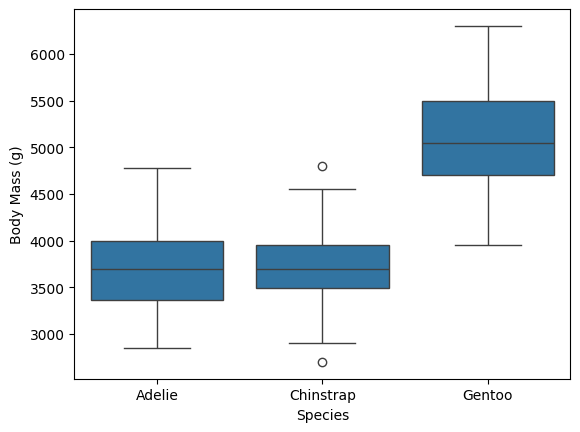

In [48]:
sns.boxplot(x = 'Species', y = 'Body Mass (g)', data= penguins);


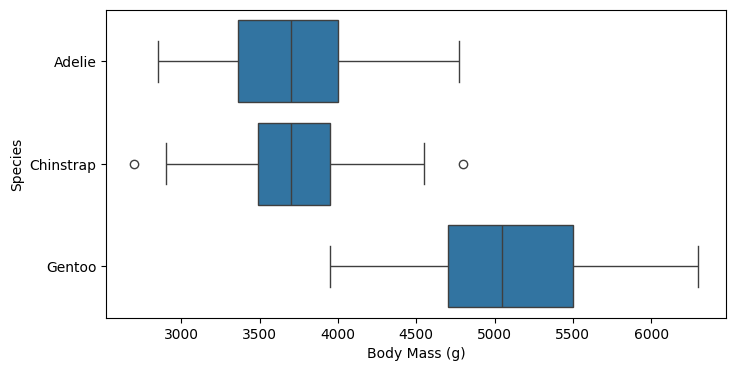

In [18]:
# show body_mass_g per island in a box plot

plt.subplots(figsize = (8,4))

sns.boxplot(y = 'Species', x = 'Body Mass (g)',
            data=penguins);

In [20]:
penguins['Species'].value_counts() # normalize=True returns the share values


,count
Species,
Adelie,146
Gentoo,119
Chinstrap,68


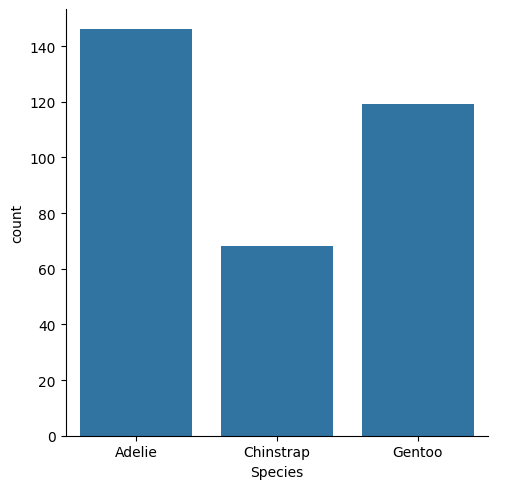

In [21]:
# we can get the count of each species

sns.catplot(x='Species', data=penguins, kind='count');

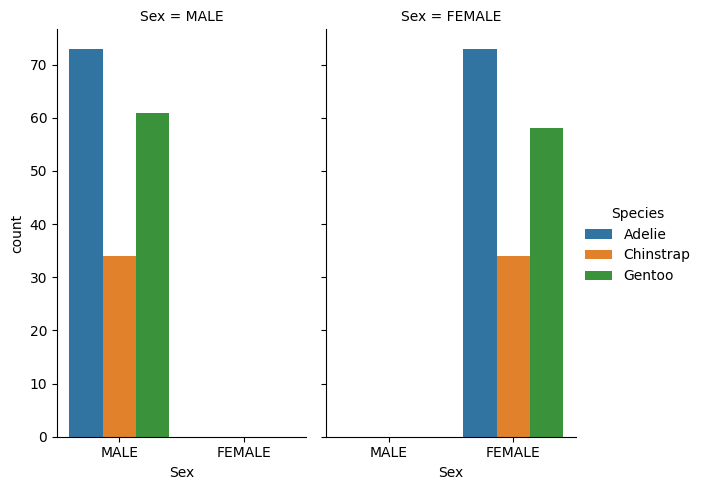

In [22]:
# using the advantages FacetGrid...

sns.catplot(x='Sex', data=penguins, kind='count',
            hue='Species',
            col='Sex',
            height = 5, aspect = 0.6);    # size

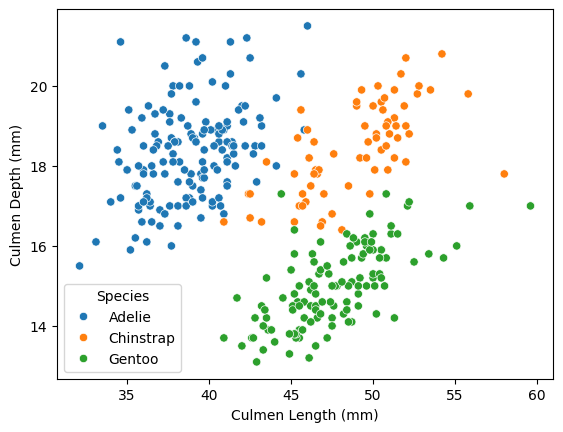

In [50]:
sns.scatterplot(x='Culmen Length (mm)', y='Culmen Depth (mm)', data=penguins, hue='Species'
               );